<a href="https://colab.research.google.com/github/rahafabumwise/WiDS-Global-Datathon-2026/blob/main/kaggle_fire_comp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os

Mounted at /content/drive


In [2]:
path = "/content/drive/MyDrive/WiDS Global Datathon 2026/WiDSWorldWide_GlobalDathon26"

In [3]:
import pandas as pd
train = pd.read_csv(path+"/train.csv")
test = pd.read_csv(path+"/test.csv")
smp_submission = pd.read_csv(path+"/sample_submission.csv")
metaData = pd.read_csv(path+"/metaData.csv")

In [ ]:
train

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,97075632,1,0.000000,1,51.295195,0.000000,0.000000,0.000000,3.956904,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,17,6,6,66.340624,0
217,97362560,2,1.127102,0,1.176991,0.000000,0.000000,0.000000,0.777943,0.000000,...,0.000000,-0.277779,0.277779,-0.000000,-0.000000,18,1,7,5.694898,1
218,97805715,2,3.710653,0,71.946930,0.000000,0.000000,0.000000,4.289732,0.000000,...,0.000000,0.694609,0.694609,0.000000,0.000000,18,1,9,44.011253,0
219,99071478,1,0.000000,1,20.223659,0.000000,0.000000,0.000000,3.055117,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,15,0,8,22.975783,1


In [ ]:
test

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
0,10662602,1,0.000000,1,2.452217,0.000000,0.00000,0.000000,1.239017,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,3,7
1,13353600,1,0.000000,1,131.669588,0.000000,0.00000,0.000000,4.887862,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22,0,8
2,13942327,1,0.000000,1,6.723104,0.000000,0.00000,0.000000,2.044216,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2,6,7
3,16112781,1,0.000000,1,285.416736,0.000000,0.00000,0.000000,5.657448,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,7
4,17132808,7,3.459331,0,61.098604,12.516633,0.20486,3.618224,4.128724,2.603921,...,13.54413,-22.687575,0.044572,0.158550,0.158550,-24.414806,3.920562,23,5,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,94627327,2,4.614923,0,24.438326,0.000000,0.00000,0.000000,3.236257,0.000000,...,0.00000,0.000000,0.000000,0.763809,0.763809,0.000000,0.000000,22,0,6
91,96570675,1,0.000000,1,155.843418,0.000000,0.00000,0.000000,5.055248,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21,2,7
92,97225766,1,0.000000,1,87.761553,0.000000,0.00000,0.000000,4.485954,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4,1,7
93,98446281,2,4.335964,0,11.391108,0.000000,0.00000,0.000000,2.516979,0.000000,...,0.00000,0.000000,0.000000,-0.305683,0.305683,0.000000,-0.000000,17,0,9


In [ ]:
smp_submission

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.5,0.5,0.5,0.5
1,13353600,0.5,0.5,0.5,0.5
2,13942327,0.5,0.5,0.5,0.5
3,16112781,0.5,0.5,0.5,0.5
4,17132808,0.5,0.5,0.5,0.5
...,...,...,...,...,...
90,94627327,0.5,0.5,0.5,0.5
91,96570675,0.5,0.5,0.5,0.5
92,97225766,0.5,0.5,0.5,0.5
93,98446281,0.5,0.5,0.5,0.5


In [ ]:
metaData

,column,type,category,description,units,range
0,event_id,identifier,identifier,Anonymized fire event identifier (stable rando...,NaN,NaN
1,time_to_hit_hours,target,target,Time from t0+5h until fire comes within 5km of...,hours,"[0, 72]"
2,event,target,target,"Event indicator: 1 if fire hit within 72h, 0 i...",NaN,NaN
3,num_perimeters_0_5h,feature,temporal_coverage,Number of perimeters within first 5 hours,NaN,NaN
4,dt_first_last_0_5h,feature,temporal_coverage,Time span between first and last perimeter (ho...,NaN,NaN
5,low_temporal_resolution_0_5h,feature,temporal_coverage,"Flag: 1 if dt < 0.5h or only 1 perimeter, else 0",NaN,NaN
6,area_first_ha,feature,growth,Initial fire area at t0 (hectares),NaN,NaN
7,area_growth_abs_0_5h,feature,growth,Feature from growth category,NaN,NaN
8,area_growth_rel_0_5h,feature,growth,Feature from growth category,NaN,NaN
9,area_growth_rate_ha_per_h,feature,growth,Area growth rate (hectares per hour),NaN,NaN


In [ ]:
for i in range(len(metaData)):
  row = metaData.iloc[i]
  print("-"*50)
  for column in metaData:
    print(column + ": " + str(row[column]))

--------------------------------------------------
column: event_id
type: identifier
category: identifier
description: Anonymized fire event identifier (stable random remap, no temporal meaning)
units: nan
range: nan
--------------------------------------------------
column: time_to_hit_hours
type: target
category: target
description: Time from t0+5h until fire comes within 5km of evac zone (hours). For censored events (never hit within 72h), this is the last observed time within the window (≤ 72). Used for training survival models.
units: hours
range: [0, 72]
--------------------------------------------------
column: event
type: target
category: target
description: Event indicator: 1 if fire hit within 72h, 0 if censored (never hit)
units: nan
range: nan
--------------------------------------------------
column: num_perimeters_0_5h
type: feature
category: temporal_coverage
description: Number of perimeters within first 5 hours
units: nan
range: nan
------------------------------------

In [ ]:
def feature_engineering(df):

    data = df.copy()

    speed = data['closing_speed_m_per_h'].clip(lower=0.01)
    dist = data['dist_min_ci_0_5h'].clip(lower=1)

    data['danger_vector'] = data['alignment_abs'] * speed

    data['tracking_urgency'] = data['num_perimeters_0_5h'] * speed

    data['fire_intensity'] = (data['area_growth_rate_ha_per_h'] *
                                data['num_perimeters_0_5h'])

    data['speed_dist_ratio'] = speed / dist

    data['log_dist'] = np.log1p(dist)

    data['hour_sin'] = np.sin(2 * np.pi * data['event_start_hour']/24.0)
    data['hour_cos'] = np.cos(2 * np.pi * data['event_start_hour']/24.0)

    # Clean infinities / NaN
    data = data.replace([np.inf, -np.inf], np.nan).fillna(0)

    return data

In [ ]:
train = feature_engineering(train)
test  = feature_engineering(test)

In [4]:
import numpy as np

for i in [12, 24, 48, 60,72]:
    col = f"y_{i}h"
    train[col] = np.nan

    for j in range(len(train)):
        event = train.loc[j, "event"]
        t = train.loc[j, "time_to_hit_hours"]

        if event == 1 and t <= i:
            train.loc[j, col] = 1

        elif event == 1 and t > i:
            train.loc[j, col] = 0

        elif event == 0 and t >= i:
            train.loc[j, col] = 0

        # elif event == 0 and t < i:
        #     leave as NaN because label is unknown

In [ ]:
train

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,y_24h,y_48h,y_72h,danger_vector,tracking_urgency,fire_intensity,speed_dist_ratio,log_dist,hour_sin,hour_cos
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,NaN,NaN,NaN,0.000546,0.03,2.022842,1.621765e-06,8.726987,-0.965926,2.588190e-01
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,1.0,1.0,1.0,0.005689,0.02,0.000000,3.411891e-06,7.983415,0.866025,5.000000e-01
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,1.0,1.0,1.0,0.008824,0.04,0.000000,3.055884e-06,8.093577,-0.500000,8.660254e-01
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.0,0.0,NaN,0.000000,0.01,0.000000,1.559579e-07,11.068525,-0.866025,5.000000e-01
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.0,NaN,NaN,0.009346,0.02,0.000000,5.553879e-07,9.798484,-0.707107,7.071068e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,97075632,1,0.000000,1,51.295195,0.000000,0.000000,0.000000,3.956904,0.000000,...,0.0,0.0,NaN,0.000000,0.01,0.000000,3.568469e-08,12.543377,-0.965926,-2.588190e-01
217,97362560,2,1.127102,0,1.176991,0.000000,0.000000,0.000000,0.777943,0.000000,...,1.0,1.0,1.0,0.002778,0.02,0.000000,2.200245e-06,8.421992,-1.000000,-1.836970e-16
218,97805715,2,3.710653,0,71.946930,0.000000,0.000000,0.000000,4.289732,0.000000,...,0.0,NaN,NaN,0.006946,0.02,0.000000,1.657914e-06,8.704946,-1.000000,-1.836970e-16
219,99071478,1,0.000000,1,20.223659,0.000000,0.000000,0.000000,3.055117,0.000000,...,1.0,1.0,1.0,0.000000,0.01,0.000000,2.139562e-06,8.449953,-0.707107,-7.071068e-01


In [5]:
for i in [12, 24, 48,60, 72]:
  print(train[f"y_{i}h"].value_counts())


y_12h
0.0    166
1.0     49
Name: count, dtype: int64
y_24h
0.0    133
1.0     63
Name: count, dtype: int64
y_48h
0.0    100
1.0     66
Name: count, dtype: int64
y_60h
0.0    82
1.0    68
Name: count, dtype: int64
y_72h
1.0    69
Name: count, dtype: int64


In [6]:
train[["y_12h","y_24h","y_48h","y_72h","y_60h"]].isna().sum()

,0
y_12h,6
y_24h,25
y_48h,55
y_72h,152
y_60h,71


<Axes: >

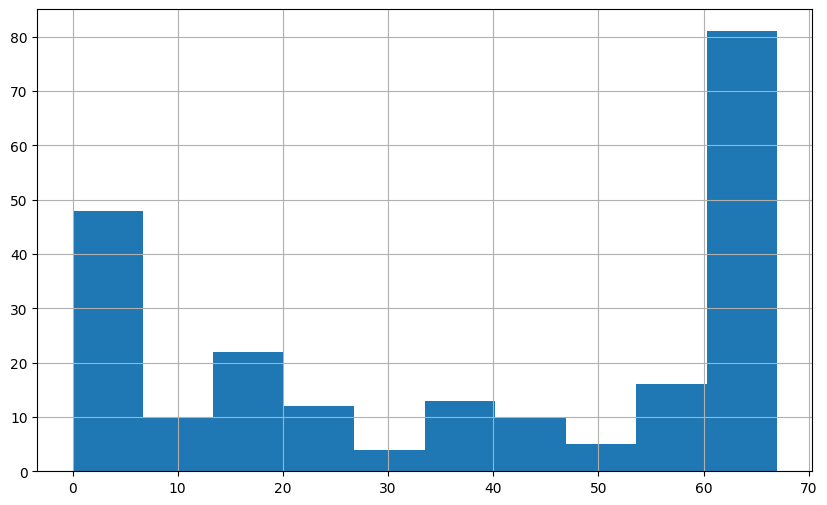

In [ ]:
train["time_to_hit_hours"].hist(figsize=(10,6))

In [ ]:
train.describe()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event,y_12h,y_24h,y_48h,y_72h
count,2.210000e+02,221.000000,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000,221.000000,...,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,215.000000,196.000000,166.000000,69.0
mean,5.384397e+07,2.063348,0.979869,0.728507,619.131641,26.332398,1.789087e-01,6.167128,4.683276,0.389346,...,0.551690,15.429864,2.841629,6.782805,37.567626,0.312217,0.227907,0.321429,0.397590,1.0
std,2.507456e+07,2.578859,1.738052,0.445739,1447.723668,187.437018,1.302001e+00,40.467370,2.083529,1.340348,...,46.760648,7.921250,1.974217,1.571876,25.902361,0.464450,0.420461,0.468221,0.490881,0.0
min,1.089246e+07,1.000000,0.000000,0.000000,0.037525,-0.000022,-1.437844e-07,-0.000005,0.036838,0.000000,...,-526.597241,0.000000,0.000000,1.000000,0.001220,0.000000,0.000000,0.000000,0.000000,1.0
25%,3.209326e+07,1.000000,0.000000,0.000000,25.219058,0.000000,0.000000e+00,0.000000,3.266487,0.000000,...,0.000000,9.000000,1.000000,6.000000,12.242322,0.000000,0.000000,0.000000,0.000000,1.0
50%,5.244094e+07,1.000000,0.000000,1.000000,110.149250,0.000000,0.000000e+00,0.000000,4.710874,0.000000,...,0.000000,19.000000,3.000000,7.000000,43.109830,0.000000,0.000000,0.000000,0.000000,1.0
75%,7.457274e+07,2.000000,1.356107,1.000000,485.092561,0.000000,0.000000e+00,0.000000,6.186399,0.000000,...,0.000000,21.000000,5.000000,8.000000,63.938706,1.000000,0.000000,1.000000,1.000000,1.0
max,9.933973e+07,17.000000,4.994457,1.000000,11942.392115,2508.041442,1.788970e+01,520.443033,9.387933,7.827656,...,383.099186,23.000000,6.000000,9.000000,66.994474,1.000000,1.000000,1.000000,1.000000,1.0


##baseline

#12

In [7]:
train_12 = train.dropna(subset=["y_12h"])
train_12

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event,y_12h,y_24h,y_48h,y_60h,y_72h
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,19,4,5,18.892512,0,0.0,NaN,NaN,NaN,NaN
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,4,4,6,22.048108,1,0.0,1.0,1.0,1.0,1.0
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,22,4,8,0.888895,1,1.0,1.0,1.0,1.0,1.0
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,20,5,8,60.953021,0,0.0,0.0,0.0,0.0,NaN
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,21,5,7,44.990274,0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,96372213,1,0.000000,1,169.688297,0.000000,0.000000,0.000000,5.139839,0.000000,...,21,0,6,43.109830,0,0.0,0.0,NaN,NaN,NaN
216,97075632,1,0.000000,1,51.295195,0.000000,0.000000,0.000000,3.956904,0.000000,...,17,6,6,66.340624,0,0.0,0.0,0.0,0.0,NaN
217,97362560,2,1.127102,0,1.176991,0.000000,0.000000,0.000000,0.777943,0.000000,...,18,1,7,5.694898,1,1.0,1.0,1.0,1.0,1.0
218,97805715,2,3.710653,0,71.946930,0.000000,0.000000,0.000000,4.289732,0.000000,...,18,1,9,44.011253,0,0.0,0.0,NaN,NaN,NaN


In [8]:
y_12 = train_12["y_12h"]
X_12 = train_12.drop(columns=["event_id","time_to_hit_hours","event","y_12h","y_24h","y_48h","y_72h","y_60h"])

In [9]:
import lightgbm as lgb

lgbm_12 = lgb.LGBMClassifier()
lgbm_12.fit(X_12,y_12)


[LightGBM] [Info] Number of positive: 49, number of negative: 166
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000264 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 451
[LightGBM] [Info] Number of data points in the train set: 215, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.227907 -> initscore=-1.220167
[LightGBM] [Info] Start training from score -1.220167
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier()

In [10]:
X_test_12 = test[X_12.columns]

test_12_proba = lgbm_12.predict_proba(X_test_12)[:, 1]

In [11]:
smp_submission["prob_12h"] = test_12_proba

#24

In [12]:
train_24 = train.dropna(subset=["y_24h"])
train_24

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event,y_12h,y_24h,y_48h,y_60h,y_72h
1,11757157,2,1.169918,0,8.946749,0.0,0.0,0.0,2.297246,0.0,...,4,4,6,22.048108,1,0.0,1.0,1.0,1.0,1.0
2,11945086,4,4.777526,0,106.482638,0.0,0.0,0.0,4.677329,0.0,...,22,4,8,0.888895,1,1.0,1.0,1.0,1.0,1.0
3,12044083,1,0.000000,1,67.631125,0.0,0.0,0.0,4.228746,0.0,...,20,5,8,60.953021,0,0.0,0.0,0.0,0.0,NaN
4,12052347,2,4.975273,0,35.632874,0.0,0.0,0.0,3.600946,0.0,...,21,5,7,44.990274,0,0.0,0.0,NaN,NaN,NaN
5,12773599,1,0.000000,1,184.767610,0.0,0.0,0.0,5.224496,0.0,...,0,5,7,44.026384,0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,96372213,1,0.000000,1,169.688297,0.0,0.0,0.0,5.139839,0.0,...,21,0,6,43.109830,0,0.0,0.0,NaN,NaN,NaN
216,97075632,1,0.000000,1,51.295195,0.0,0.0,0.0,3.956904,0.0,...,17,6,6,66.340624,0,0.0,0.0,0.0,0.0,NaN
217,97362560,2,1.127102,0,1.176991,0.0,0.0,0.0,0.777943,0.0,...,18,1,7,5.694898,1,1.0,1.0,1.0,1.0,1.0
218,97805715,2,3.710653,0,71.946930,0.0,0.0,0.0,4.289732,0.0,...,18,1,9,44.011253,0,0.0,0.0,NaN,NaN,NaN


In [14]:
y_24 = train_24["y_24h"]
X_24 = train_24.drop(columns=["event_id","time_to_hit_hours","event","y_12h","y_24h","y_48h","y_72h","y_60h"])

In [15]:
import lightgbm as lgb

lgbm_24 = lgb.LGBMClassifier()

In [16]:
lgbm_24.fit(X_24,y_24)

[LightGBM] [Info] Number of positive: 63, number of negative: 133
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 416
[LightGBM] [Info] Number of data points in the train set: 196, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.321429 -> initscore=-0.747214
[LightGBM] [Info] Start training from score -0.747214
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier()

In [17]:
# 2) Build test features with the exact same feature columns
X_test_24 = test[X_24.columns]

# 3) Predict probabilities on test
test_24_proba = lgbm_24.predict_proba(X_test_24)[:, 1]

# optional: look at the first few probabilities
print(test_24_proba[:10])

[3.13200397e-04 9.99685069e-01 7.70002686e-04 9.90847168e-01
 1.33599697e-03 1.58767130e-04 6.02875535e-04 9.96964488e-01
 8.88600389e-05 9.95877044e-01]


In [18]:
smp_submission["prob_24h"] = test_24_proba

In [19]:
print(smp_submission["prob_24h"].describe())

count    95.000000
mean      0.277984
std       0.442405
min       0.000007
25%       0.000167
50%       0.000427
75%       0.936267
max       0.999743
Name: prob_24h, dtype: float64


In [20]:
smp_submission

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.000204,0.000313,0.5,0.5
1,13353600,0.339659,0.999685,0.5,0.5
2,13942327,0.000092,0.000770,0.5,0.5
3,16112781,0.914614,0.990847,0.5,0.5
4,17132808,0.003709,0.001336,0.5,0.5
...,...,...,...,...,...
90,94627327,0.001868,0.000912,0.5,0.5
91,96570675,0.000178,0.000169,0.5,0.5
92,97225766,0.000324,0.000447,0.5,0.5
93,98446281,0.003333,0.002389,0.5,0.5


#48

In [21]:
train_48 = train.dropna(subset=["y_48h"])

In [22]:
y_48 = train_48["y_48h"]
X_48 = train_48.drop(columns=["event_id","time_to_hit_hours","event","y_12h","y_24h","y_48h","y_72h","y_60h"])

In [23]:
lgbm_48 = lgb.LGBMClassifier()
lgbm_48.fit(X_48,y_48)

[LightGBM] [Info] Number of positive: 66, number of negative: 100
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 306
[LightGBM] [Info] Number of data points in the train set: 166, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.397590 -> initscore=-0.415515
[LightGBM] [Info] Start training from score -0.415515
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier()

In [24]:
X_test_48= test[X_48.columns]

test_48_proba = lgbm_48.predict_proba(X_test_48)[:, 1]

In [27]:
train_60 = train.dropna(subset=["y_60h"])
y_60 = train_60["y_60h"]
X_60 = train_60.drop(columns=["event_id","time_to_hit_hours","event","y_12h","y_24h","y_48h","y_72h","y_60h"])
lgbm_60 = lgb.LGBMClassifier()
lgbm_60.fit(X_60,y_60)
X_test_60= test[X_60.columns]
test_60_proba = lgbm_60.predict_proba(X_test_60)[:, 1]
smp_submission["prob_72h"] = test_60_proba

[LightGBM] [Info] Number of positive: 68, number of negative: 82
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 258
[LightGBM] [Info] Number of data points in the train set: 150, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.453333 -> initscore=-0.187212
[LightGBM] [Info] Start training from score -0.187212
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [25]:
smp_submission["prob_48h"] = test_48_proba
smp_submission["prob_72h"] = test_48_proba

In [28]:
smp_submission

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.000204,0.000313,0.000191,0.000131
1,13353600,0.339659,0.999685,0.999937,0.999970
2,13942327,0.000092,0.000770,0.000419,0.000131
3,16112781,0.914614,0.990847,0.999906,0.999857
4,17132808,0.003709,0.001336,0.000530,0.000068
...,...,...,...,...,...
90,94627327,0.001868,0.000912,0.000530,0.000109
91,96570675,0.000178,0.000169,0.000025,0.000020
92,97225766,0.000324,0.000447,0.000320,0.000122
93,98446281,0.003333,0.002389,0.000652,0.000139


In [31]:
import numpy as np

# check bad rows before fixing
bad_rows = smp_submission[
    (smp_submission["prob_12h"] > smp_submission["prob_24h"]) |
    (smp_submission["prob_24h"] > smp_submission["prob_48h"]) |
    (smp_submission["prob_48h"] > smp_submission["prob_72h"])
]

print("Number of bad rows before fix:", len(bad_rows))

# monotonic fix
smp_submission["prob_24h"] = np.maximum(smp_submission["prob_24h"], smp_submission["prob_12h"])
smp_submission["prob_48h"] = np.maximum(smp_submission["prob_48h"], smp_submission["prob_24h"])
smp_submission["prob_72h"] = np.maximum(smp_submission["prob_72h"], smp_submission["prob_48h"])

# check again
bad_rows_after = smp_submission[
    (smp_submission["prob_12h"] > smp_submission["prob_24h"]) |
    (smp_submission["prob_24h"] > smp_submission["prob_48h"]) |
    (smp_submission["prob_48h"] > smp_submission["prob_72h"])
]

print("Number of bad rows after fix:", len(bad_rows_after))

# save
smp_submission.to_csv("baseline_submission1.csv", index=False)

Number of bad rows before fix: 0
Number of bad rows after fix: 0


#sum 2

In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=45ba6c51975affce250d909a7426d16f2c8ba85ed66de89808d8c4d5e81783b5
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
from lifelines import CoxPHFitter

In [ ]:
train_cox=train.drop(columns=["event_id"])
train_cox

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,0.03545,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,0.00000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,0.00000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,0.00000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,1,0.000000,1,51.295195,0.000000,0.000000,0.000000,3.956904,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,17,6,6,66.340624,0
217,2,1.127102,0,1.176991,0.000000,0.000000,0.000000,0.777943,0.000000,0.00000,...,0.000000,-0.277779,0.277779,-0.000000,-0.000000,18,1,7,5.694898,1
218,2,3.710653,0,71.946930,0.000000,0.000000,0.000000,4.289732,0.000000,0.00000,...,0.000000,0.694609,0.694609,0.000000,0.000000,18,1,9,44.011253,0
219,1,0.000000,1,20.223659,0.000000,0.000000,0.000000,3.055117,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,15,0,8,22.975783,1


In [ ]:
cph = CoxPHFitter(penalizer=0.0004)
cph.fit(train_cox, duration_col="time_to_hit_hours", event_col="event")

<lifelines.CoxPHFitter: fitted with 221 total observations, 152 right-censored observations>

In [ ]:
# full printed summary
cph.print_summary()

# dataframe version
summary_df = cph.summary

# most useful columns
summary_df = summary_df[["coef", "exp(coef)", "se(coef)", "p"]]

# sort by strongest absolute effect
summary_df = summary_df.reindex(summary_df["coef"].abs().sort_values(ascending=False).index)

summary_df

<lifelines.CoxPHFitter: fitted with 221 total observations, 152 right-censored observations>
             duration col = 'time_to_hit_hours'
                event col = 'event'
                penalizer = 0.0004
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 221
number of events observed = 69
   partial log-likelihood = -238.62
         time fit was run = 2026-03-28 19:20:30 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
num_perimeters_0_5h            1.05      2.85      0.25            0.56            1.54                1.74                4.65
dt_first_last_0_5h            -0.44      0.64      0.23           -0.90            0.01                0.41                1.01
low_temporal_resolution_0_5h  -0.08      0.92      0.78           -1.61            1.45                0.20                4.27
area_first_ha                 -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
area_growth_abs_0_5h          -0.00      1.00      0.01           -0.03            0.02                0.97                1.02
area_growth_rel_0_5h           1.37      3.94      1.94           -2.43            5.17                0.09              175.60
area_growth_rate_ha_per_h      0.00      1.00      0.06           -0.12            0.12                0.89                1.13
log1p_area_first               0.21      1.24      0.12           -0.02            0.45                0.98                1.57
log1p_growth                   0.19      1.20      0.44           -0.69            1.06                0.50                2.88
log_area_ratio_0_5h          -10.64      0.00      4.34          -19.15           -2.14                0.00                0.12
relative_growth_0_5h           1.37      3.94      1.94           -2.43            5.17                0.09              175.60
radial_growth_m                0.01      1.01      0.02           -0.02            0.04                0.98                1.04
radial_growth_rate_m_per_h     0.03      1.03      0.06           -0.10            0.15                0.91                1.16
centroid_displacement_m       -0.01      0.99      0.01           -0.03            0.02                0.97                1.02
centroid_speed_m_per_h        -0.04      0.96      0.04           -0.11            0.04                0.90                1.04
spread_bearing_deg            -0.02      0.98      0.01           -0.05            0.00                0.96                1.00
spread_bearing_sin            -2.00      0.13      1.15           -4.26            0.25                0.01                1.29
spread_bearing_cos            -0.12      0.89      1.13           -2.34            2.10                0.10                8.19
dist_min_ci_0_5h              -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
dist_std_ci_0_5h               0.01      1.01      0.04           -0.07            0.09                0.94                1.09
dist_change_ci_0_5h            0.00      1.00      0.02           -0.04            0.04                0.96                1.04
dist_slope_ci_0_5h             0.04      1.04      0.07           -0.09            0.17                0.92                1.18
closing_speed_m_per_h         -0.02      0.98      0.11           -0.24            0.19                0.79                1.21
closing_speed_abs_m_per_h      0.05      1.05      0.09           -0.12            0.23                0.89                1.26
projected_advance_m           -0.00      1.00      0.02           -0.04            0.04                0.96                1.04
dist_accel_m_per_h2           -0.02      0.98      0.08           -0.18            0.15                0.84 

,coef,exp(coef),se(coef),p
covariate,,,,
log_area_ratio_0_5h,-10.642200,0.000024,4.338788,1.417472e-02
dist_fit_r2_0_5h,3.802472,44.811819,1.940828,5.008927e-02
spread_bearing_sin,-2.002918,0.134941,1.150221,8.162525e-02
alignment_abs,1.647911,5.196116,1.000086,9.940001e-02
relative_growth_0_5h,1.370471,3.937204,1.937648,4.793890e-01
area_growth_rel_0_5h,1.370471,3.937204,1.937648,4.793890e-01
num_perimeters_0_5h,1.046644,2.848076,0.250627,2.965395e-05
alignment_cos,-0.930144,0.394497,0.404561,2.149669e-02
dt_first_last_0_5h,-0.443418,0.641839,0.230417,5.430260e-02


In [ ]:
X_test = test.drop(columns="event_id")
X_test

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
0,1,0.000000,1,2.452217,0.000000,0.00000,0.000000,1.239017,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,3,7
1,1,0.000000,1,131.669588,0.000000,0.00000,0.000000,4.887862,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22,0,8
2,1,0.000000,1,6.723104,0.000000,0.00000,0.000000,2.044216,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2,6,7
3,1,0.000000,1,285.416736,0.000000,0.00000,0.000000,5.657448,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,7
4,7,3.459331,0,61.098604,12.516633,0.20486,3.618224,4.128724,2.603921,0.186363,...,13.54413,-22.687575,0.044572,0.158550,0.158550,-24.414806,3.920562,23,5,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,2,4.614923,0,24.438326,0.000000,0.00000,0.000000,3.236257,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.763809,0.763809,0.000000,0.000000,22,0,6
91,1,0.000000,1,155.843418,0.000000,0.00000,0.000000,5.055248,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21,2,7
92,1,0.000000,1,87.761553,0.000000,0.00000,0.000000,4.485954,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4,1,7
93,2,4.335964,0,11.391108,0.000000,0.00000,0.000000,2.516979,0.000000,0.000000,...,0.00000,0.000000,0.000000,-0.305683,0.305683,0.000000,-0.000000,17,0,9


In [ ]:
times = [12, 24, 48, 72]
surv_test = cph.predict_survival_function(X_test, times=times)
surv_test

,0,1,2,3,4,5,6,7,8,9,...,85,86,87,88,89,90,91,92,93,94
12.0,0.999954,0.421163,0.957842,0.567225,0.806289,0.999997,1.0,0.964814,0.997360,0.624321,...,0.999975,0.0,0.975484,1.133728e-12,0.448691,0.889090,0.932518,0.999987,0.999626,0.999936
24.0,0.999914,0.196324,0.922110,0.343883,0.666739,0.999994,1.0,0.934788,0.995036,0.411934,...,0.999952,0.0,0.954345,3.242839e-23,0.221178,0.801462,0.876750,0.999975,0.999296,0.999879
48.0,0.999896,0.140340,0.906819,0.275941,0.613274,0.999993,1.0,0.921879,0.994016,0.343086,...,0.999942,0.0,0.945194,7.474204e-28,0.162041,0.765708,0.853289,0.999970,0.999151,0.999854
72.0,0.999690,0.002844,0.746759,0.021408,0.232302,0.999978,1.0,0.784397,0.982240,0.041017,...,0.999827,0.0,0.845120,1.036002e-81,0.004369,0.450689,0.622718,0.999910,0.997469,0.999565


In [ ]:
prob_test = 1 - surv_test
prob_test

,0,1,2,3,4,5,6,7,8,9,...,85,86,87,88,89,90,91,92,93,94
12.0,0.000046,0.578837,0.042158,0.432775,0.193711,0.000003,7.429224e-11,0.035186,0.002640,0.375679,...,0.000025,1.0,0.024516,1.0,0.551309,0.110910,0.067482,0.000013,0.000374,0.000064
24.0,0.000086,0.803676,0.077890,0.656117,0.333261,0.000006,1.398657e-10,0.065212,0.004964,0.588066,...,0.000048,1.0,0.045655,1.0,0.778822,0.198538,0.123250,0.000025,0.000704,0.000121
48.0,0.000104,0.859660,0.093181,0.724059,0.386726,0.000007,1.687067e-10,0.078121,0.005984,0.656914,...,0.000058,1.0,0.054806,1.0,0.837959,0.234292,0.146711,0.000030,0.000849,0.000146
72.0,0.000310,0.997156,0.253241,0.978592,0.767698,0.000022,5.036654e-10,0.215603,0.017760,0.958983,...,0.000173,1.0,0.154880,1.0,0.995631,0.549311,0.377282,0.000090,0.002531,0.000435


In [ ]:
smp_submission["prob_12h"] = prob_test.loc[12].values
smp_submission["prob_24h"] = prob_test.loc[24].values
smp_submission["prob_48h"] = prob_test.loc[48].values
smp_submission["prob_72h"] = prob_test.loc[72].values

smp_submission.head()

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.000046,0.000086,0.000104,0.000310
1,13353600,0.578837,0.803676,0.859660,0.997156
2,13942327,0.042158,0.077890,0.093181,0.253241
3,16112781,0.432775,0.656117,0.724059,0.978592
4,17132808,0.193711,0.333261,0.386726,0.767698


In [ ]:
bad_rows = smp_submission[
    (smp_submission["prob_12h"] > smp_submission["prob_24h"]) |
    (smp_submission["prob_24h"] > smp_submission["prob_48h"]) |
    (smp_submission["prob_48h"] > smp_submission["prob_72h"])
]

print("Number of bad rows:", len(bad_rows))

Number of bad rows: 0


In [ ]:
smp_submission.to_csv("cox3_submission.csv", index=False)